In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [76]:
db_path = "../Data/logs_output.db"
conn = sqlite3.connect(db_path)

In [77]:
sql_query = "SELECT * FROM log_record"

In [78]:
df = pd.read_sql_query(sql_query, conn)

In [79]:
df.head()

,timestamp,level,user_id,action,latency_ms,error_code
0,2026-09-29 21:50:37,INFO,user_577,login,25,0
1,2026-09-29 21:50:39,INFO,user_604,login,94,0
2,2026-09-29 21:50:42,WARN,user_373,add_cart,99,0
3,2026-09-29 21:50:45,INFO,user_366,add_cart,65,0
4,2026-09-29 21:50:48,INFO,user_12,add_cart,28,0


In [80]:
df["level"].value_counts()

level
INFO     17984
WARN      1020
ERROR      996
Name: count, dtype: int64

In [81]:
df["action"].value_counts()

action
login        5090
add_cart     5044
view_item    4992
pay          4874
Name: count, dtype: int64

In [82]:
df["latency_ms"].mean()

np.float64(111.9568)

In [83]:
df["latency_ms"].median()

np.float64(62.0)

In [84]:
df["latency_ms"].max()

np.int64(1499)

In [85]:
df["latency_ms"].min()

np.int64(20)

In [86]:
df["latency_ms"].quantile(0.95)

np.float64(100.0)

In [87]:
df.groupby("action")["latency_ms"].agg(["mean", "max"])

,mean,max
action,,
add_cart,112.664552,1483
login,112.791356,1498
pay,102.443989,1499
view_item,119.678686,1487


In [88]:
error_quantity = (df["level"] == "ERROR").sum()
error_quantity / len(df)

np.float64(0.0498)

In [89]:
slow_quantity = (df["latency_ms"] > 800).sum()
slow_quantity / len(df)

np.float64(0.048)

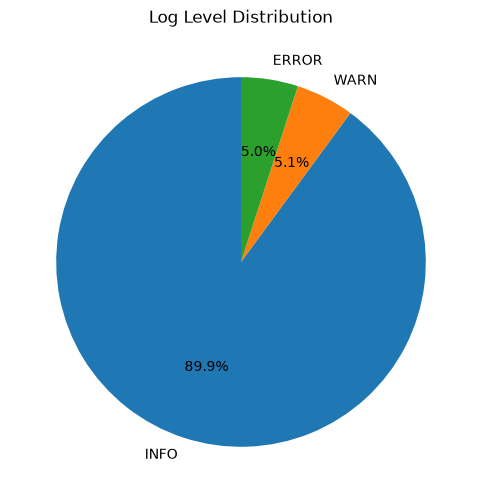

In [90]:
level_counts = df["level"].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(level_counts, labels=level_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Log Level Distribution")
plt.savefig("../Data/level_pie.png")
plt.show()

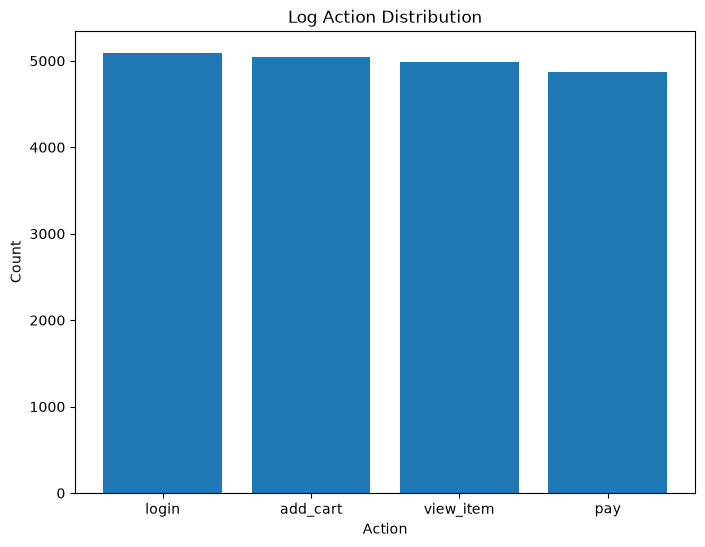

In [91]:
action_counts = df["action"].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(action_counts.index, action_counts)
plt.xlabel("Action")
plt.ylabel("Count")
plt.title("Log Action Distribution")
plt.savefig("../Data/action_bar.png")
plt.show()

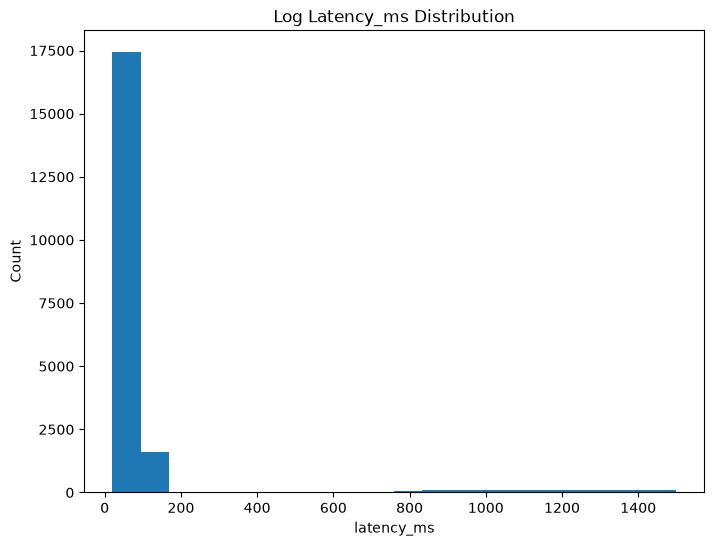

In [92]:
plt.figure(figsize=(8, 6))
plt.hist(df["latency_ms"], bins=20)
plt.xlabel("latency_ms")
plt.ylabel("Count")
plt.title("Log Latency_ms Distribution")
plt.savefig("../Data/latency_hist.png")
plt.show()

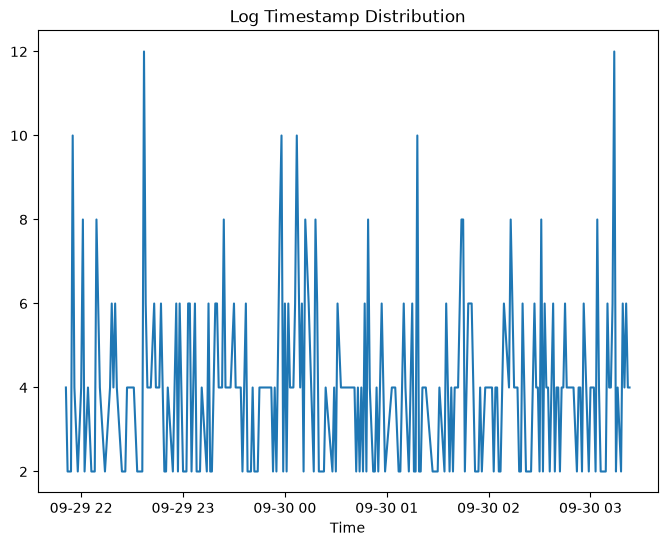

In [93]:
df["time"] = pd.to_datetime(df["timestamp"])
error_df = df[df["level"] == "ERROR"]
minute_counts = error_df.groupby(error_df["time"].dt.floor("min")).size()
plt.figure(figsize = (8, 6))
plt.plot(minute_counts.index, minute_counts.values)
plt.xlabel("Time")
plt.title("Log Timestamp Distribution")
plt.savefig("../Data/timestamp_error.png")
plt.show()

In [94]:
conn.close()